In [29]:
import pandas as pd

df = pd.read_csv(r"C:\Users\pilla\OneDrive\Documents\Desktop\Capstone\Capstone Project Data\merged_cleaned_data.csv")

print(df.head())
print(df.shape)

       City   GeoID  PovertyRate  SingleParentRate  UnemploymentRate  \
0   Buckeye  407940         8.00              5.37              4.91   
1  Chandler  412000         7.93              7.19              3.62   
2   Gilbert  427400         5.26              6.67              3.50   
3  Glendale  427820        15.11              7.70              5.61   
4  Goodyear  428380         5.25              4.71              4.18   

   YouthEnrollmentRate  Population  BurglaryRate  VacancyRate  
0                72.35    104923.0        1307.2         7.39  
1                79.63    280136.0        1689.3         4.53  
2                80.55    280262.0        1009.1         3.96  
3                72.29    252833.0        2425.7         5.44  
4                75.13    107645.0        1929.5         9.42  
(13, 9)


In [31]:
#define and target features
y = df["BurglaryRate"]

X = df[[
    "PovertyRate",
    "SingleParentRate",
    "UnemploymentRate",
    "YouthEnrollmentRate",
    "Population",
    "VacancyRate"
]]

print(X.head())

   PovertyRate  SingleParentRate  UnemploymentRate  YouthEnrollmentRate  \
0         8.00              5.37              4.91                72.35   
1         7.93              7.19              3.62                79.63   
2         5.26              6.67              3.50                80.55   
3        15.11              7.70              5.61                72.29   
4         5.25              4.71              4.18                75.13   

   Population  VacancyRate  
0    104923.0         7.39  
1    280136.0         4.53  
2    280262.0         3.96  
3    252833.0         5.44  
4    107645.0         9.42  


In [33]:
#split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (10, 6)
Test size: (3, 6)


In [35]:
#linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# Metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", round(mae_lr, 2))
print("RMSE:", round(rmse_lr, 2))
print("R2:", round(r2_lr, 4))

Linear Regression Results
MAE: 630.24
RMSE: 708.74
R2: -0.2068


In [37]:
#linear regression off by 630 burglaries per 100l, rmse is worse. 

In [39]:
#random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Results")
print("MAE:", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R2:", round(r2_rf, 4))


Random Forest Results
MAE: 453.41
RMSE: 505.38
R2: 0.3864


In [41]:
#better, random forest explains for 39% of variation.


Feature Importance:

               Feature  Importance
0          PovertyRate    0.326174
3  YouthEnrollmentRate    0.229906
2     UnemploymentRate    0.176220
5          VacancyRate    0.102738
4           Population    0.102551
1     SingleParentRate    0.062410


NameError: name 'plt' is not defined

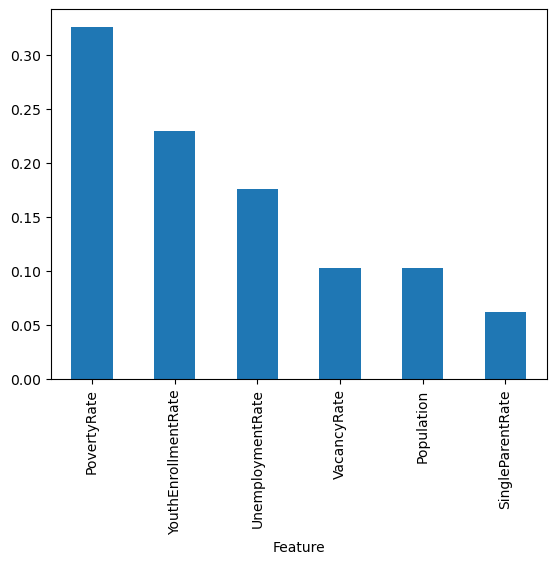

In [45]:
#feature importance
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:\n")
print(importance)

#plot
importance.plot(kind="bar", x="Feature", y="Importance", legend=False)
plt.title("Random Forest Feature Importance")
plt.show()